Name :Divyadharshini S
Roll no :24BAD022
Accuracy: 0.968609865470852
Precision: 1.0
Recall: 0.7666666666666667
F1 Score: 0.8679245283018868

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115


Number of Misclassified Messages: 35
     label                                            message
1044  spam  We know someone who you know that fancies you....
683   spam  Hi I'm sue. I am 20 years old and work as a la...
4071  spam  Loans for any purpose even if you have Bad Cre...
2312  spam  tddnewsletter@emc1.co.uk (More games from TheD...
3979  spam                                 ringtoneking 84484
2877  spam  Hey Boys. Want hot XXX pics sent direct 2 ur p...
3562  spam  Auction round 4. The hig

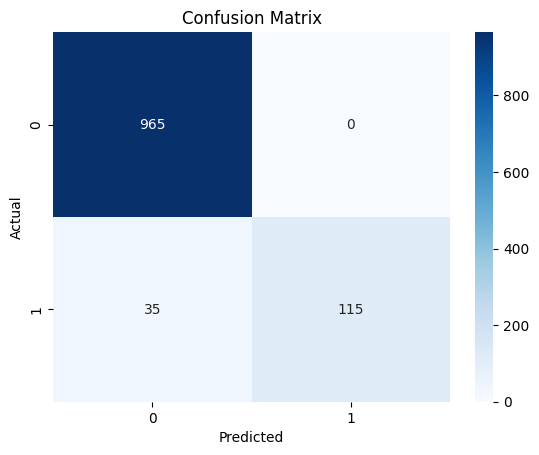

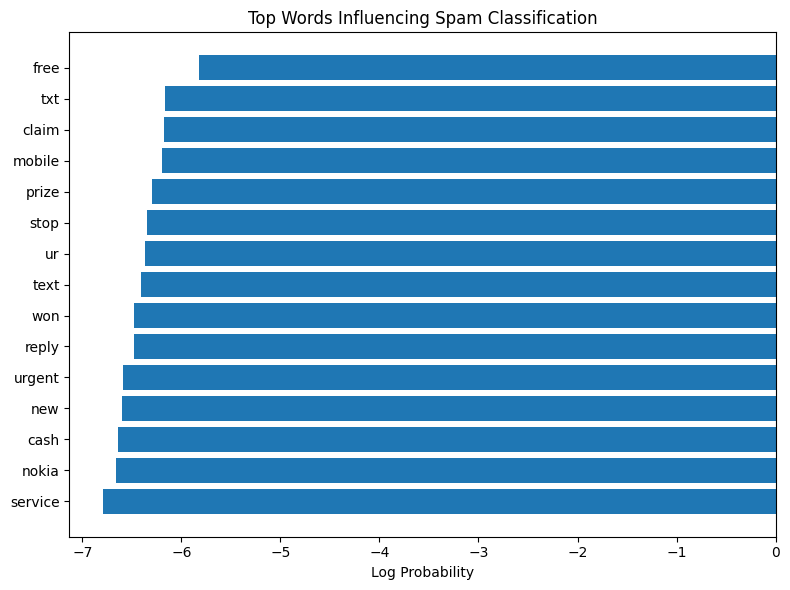

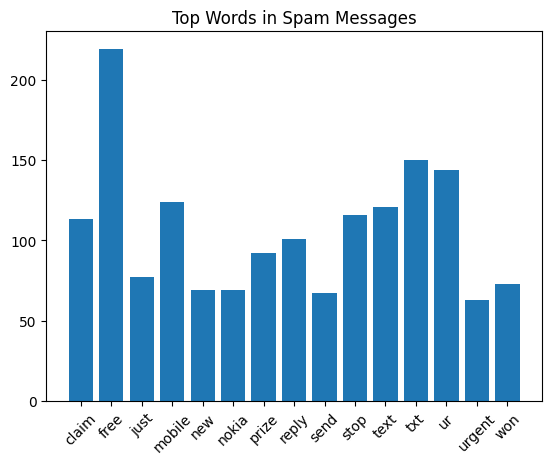

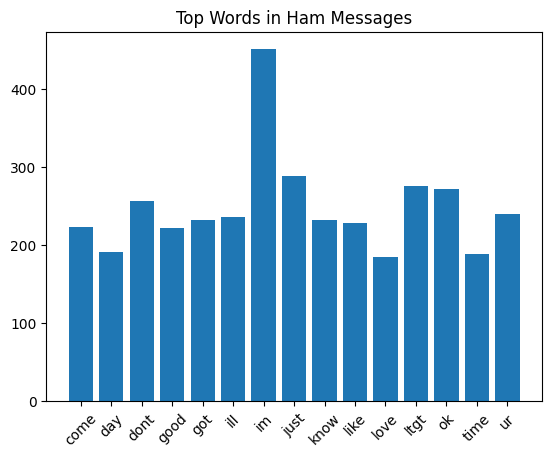

In [12]:
print("Name :Divyadharshini S\nRoll no :24BAD022")
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_message'] = df['message'].apply(clean_text)

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['cleaned_message'])

encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])

X_train, X_test, y_train, y_test, train_index, test_index = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

misclassified = df.iloc[test_index][y_test != y_pred]
print("\nNumber of Misclassified Messages:", len(misclassified))
print(misclassified[['label', 'message']].head(10))

alphas = [0.01, 0.1, 1, 5, 10]
print("\nLaplace Smoothing Impact:")
for a in alphas:
    temp_model = MultinomialNB(alpha=a)
    temp_model.fit(X_train, y_train)
    temp_pred = temp_model.predict(X_test)
    print("Alpha =", a, "Accuracy =", accuracy_score(y_test, temp_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

feature_names = np.array(vectorizer.get_feature_names_out())
spam_prob = model.feature_log_prob_[1]

top_indices = np.argsort(spam_prob)[-15:]
top_words = feature_names[top_indices]
top_scores = spam_prob[top_indices]

sorted_idx = np.argsort(top_scores)

plt.figure(figsize=(8,6))
plt.barh(top_words[sorted_idx], top_scores[sorted_idx])
plt.xlabel("Log Probability")
plt.title("Top Words Influencing Spam Classification")
plt.tight_layout()
plt.show()

spam_messages = df[df['label'] == 'spam']['cleaned_message']
ham_messages = df[df['label'] == 'ham']['cleaned_message']

spam_vectorizer = CountVectorizer(stop_words='english', max_features=15)
ham_vectorizer = CountVectorizer(stop_words='english', max_features=15)

spam_counts = spam_vectorizer.fit_transform(spam_messages)
ham_counts = ham_vectorizer.fit_transform(ham_messages)

spam_sum = np.array(spam_counts.sum(axis=0)).flatten()
ham_sum = np.array(ham_counts.sum(axis=0)).flatten()

plt.figure()
plt.bar(spam_vectorizer.get_feature_names_out(), spam_sum)
plt.xticks(rotation=45)
plt.title("Top Words in Spam Messages")
plt.show()

plt.figure()
plt.bar(ham_vectorizer.get_feature_names_out(), ham_sum)
plt.xticks(rotation=45)
plt.title("Top Words in Ham Messages")
plt.show()


Name :Divyadharshini S
Roll no :24BAD022
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000
speci

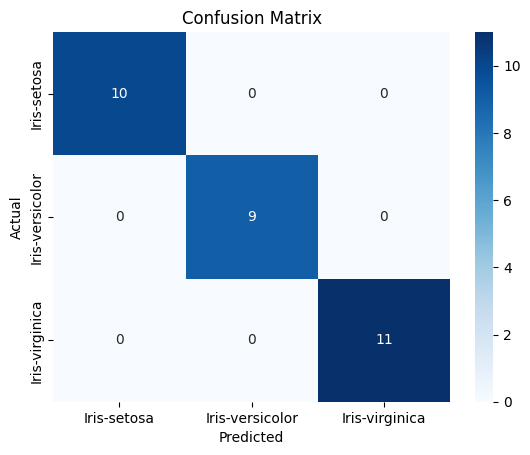

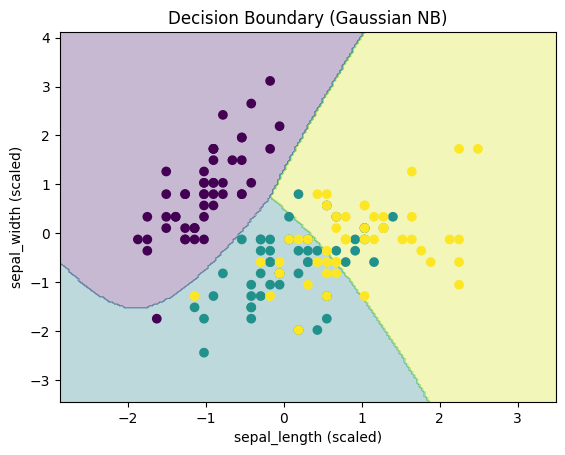

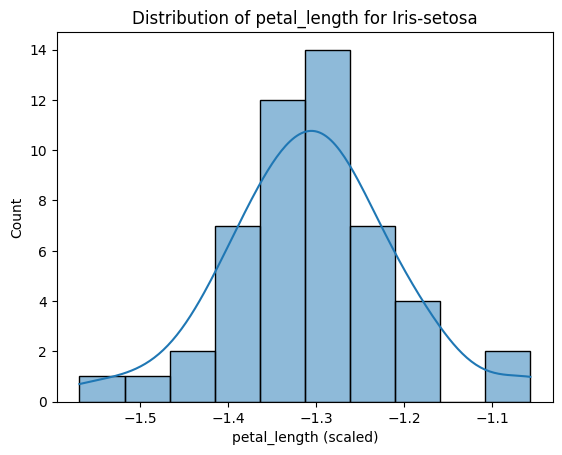

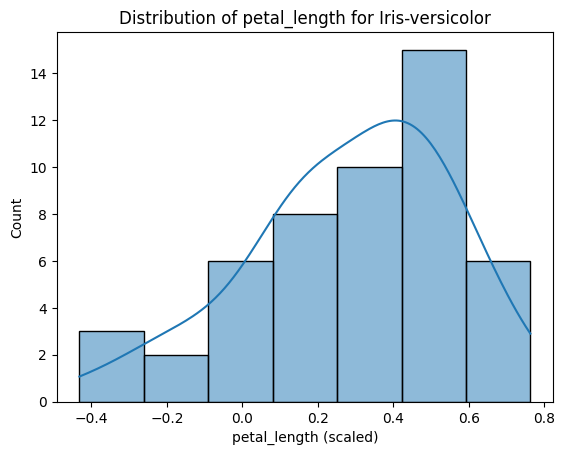

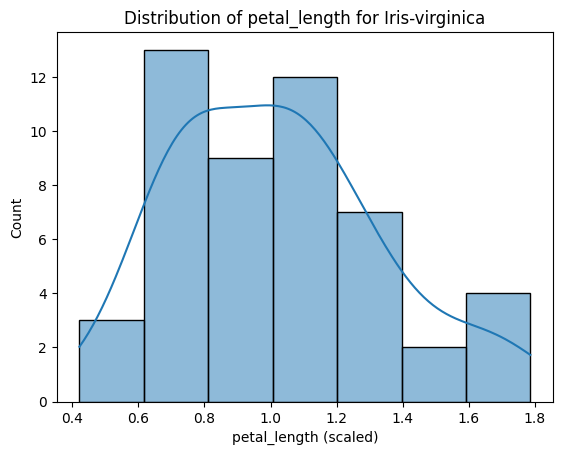

Logistic Regression Accuracy: 1.0


In [13]:
print("Name :Divyadharshini S\nRoll no :24BAD022")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

np.random.seed(42)

df = pd.read_csv("/kaggle/input/datasets/mzeeshan786/iris-dataset/IRIS.csv")

print(df.head())
print(df.describe())
print(df['species'].value_counts())

X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

encoder = LabelEncoder()
y = encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Gaussian NB Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

comparison_df = pd.DataFrame({
    "Actual": encoder.inverse_transform(y_test),
    "Predicted": encoder.inverse_transform(y_pred)
})
print("\nActual vs Predicted:\n", comparison_df.head(10))

y_prob = gnb.predict_proba(X_test)
print("\nClass Probabilities (first 5 samples):\n", y_prob[:5])

cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

X_two = X_scaled[:, :2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_two, y, test_size=0.2, random_state=42
)

gnb2 = GaussianNB()
gnb2.fit(X_train2, y_train2)

x_min, x_max = X_two[:, 0].min() - 1, X_two[:, 0].max() + 1
y_min, y_max = X_two[:, 1].min() - 1, X_two[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = gnb2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_two[:, 0], X_two[:, 1], c=y)
plt.xlabel("sepal_length (scaled)")
plt.ylabel("sepal_width (scaled)")
plt.title("Decision Boundary (Gaussian NB)")
plt.show()

for i in range(len(encoder.classes_)):
    plt.figure()
    sns.histplot(X_scaled[y == i, 2], kde=True)
    plt.title("Distribution of petal_length for " + encoder.classes_[i])
    plt.xlabel("petal_length (scaled)")
    plt.show()

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)
